In [14]:
import seaborn as sns
palette = sns.color_palette("pastel", 6)

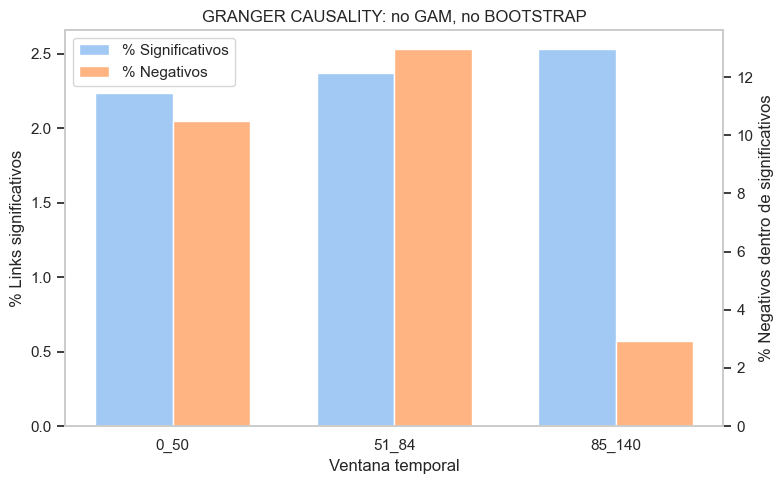

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Crear DataFrame
# -------------------------
data = {
    "ventana": ["0_50", "51_84", "85_140"],
    "pares_analizados": [5550, 4556, 4032],
    "links_significativos": [124, 108, 102],
    "negativos": [13, 14, 3],
}

df = pd.DataFrame(data)

# -------------------------
# Calcular porcentajes
# -------------------------
df["pct_significativos"] = (
    df["links_significativos"] / df["pares_analizados"] * 100
)

df["pct_negativos_dentro_sig"] = (
    df["negativos"] / df["links_significativos"] * 100
)

# -------------------------
# Estética
# -------------------------
sns.set(style="whitegrid")
palette = sns.color_palette("pastel", 2)

# -------------------------
# Gráfico
# -------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(df))
width = 0.35

# Barras eje izquierdo
bars1 = ax1.bar(
    x - width/2,
    df["pct_significativos"],
    width,
    color=palette[0]
)

ax1.set_ylabel("% Links significativos")
ax1.set_xlabel("Ventana temporal")
ax1.set_xticks(x)
ax1.set_xticklabels(df["ventana"])

# Barras eje derecho
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    df["pct_negativos_dentro_sig"],
    width,
    color=palette[1]
)

ax2.set_ylabel("% Negativos dentro de significativos")

# -------------------------
# Leyenda limpia (solo una barra de cada tipo)
# -------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=palette[0], label="% Significativos"),
    Patch(facecolor=palette[1], label="% Negativos")
]

ax1.legend(handles=legend_elements, loc="upper left")

ax1.grid(False)
ax2.grid(False)

plt.title("GRANGER CAUSALITY: no GAM, no BOOTSTRAP")
plt.tight_layout()
plt.show()

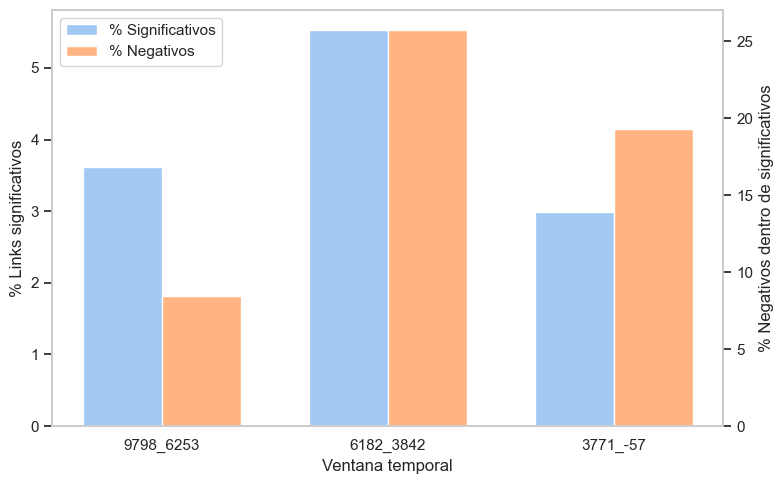

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -------------------------
# Crear DataFrame
# -------------------------
data = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "pares_analizados": [5550, 5550, 5550],
    "links_significativos": [201, 307, 166],
    "negativos": [17, 79, 32],
}

df = pd.DataFrame(data)

# -------------------------
# Calcular porcentajes
# -------------------------
df["pct_significativos"] = (
    df["links_significativos"] / df["pares_analizados"] * 100
)

df["pct_negativos_dentro_sig"] = (
    df["negativos"] / df["links_significativos"] * 100
)

# -------------------------
# Estética
# -------------------------
sns.set(style="whitegrid")
palette = sns.color_palette("pastel", 2)

fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(df))
width = 0.35

# Eje izquierdo
ax1.bar(
    x - width/2,
    df["pct_significativos"],
    width,
    color=palette[0]
)

ax1.set_ylabel("% Links significativos")
ax1.set_xlabel("Ventana temporal")
ax1.set_xticks(x)
ax1.set_xticklabels(df["ventana"])

# Eje derecho
ax2 = ax1.twinx()

ax2.bar(
    x + width/2,
    df["pct_negativos_dentro_sig"],
    width,
    color=palette[1]
)

ax2.set_ylabel("% Negativos dentro de significativos")

# Leyenda limpia
legend_elements = [
    Patch(facecolor=palette[0], label="% Significativos"),
    Patch(facecolor=palette[1], label="% Negativos")
]

ax1.legend(handles=legend_elements, loc="upper left")

ax1.grid(False)
ax2.grid(False)
#plt.title("Links significativos y proporción de negativos por ventana")
plt.tight_layout()
plt.show()

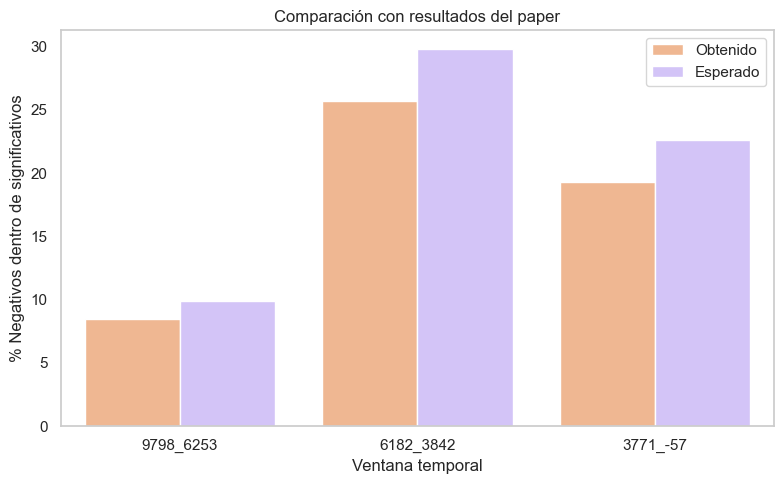

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Datos comparación paper
# -------------------------
comp_data = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [8.5, 25.7, 19.3],
    "Esperado": [9.9, 29.8, 22.6],
}

comp_df = pd.DataFrame(comp_data)

comp_df_melt = comp_df.melt(
    id_vars="ventana",
    var_name="Tipo",
    value_name="Porcentaje"
)

# -------------------------
# Paleta personalizada
# -------------------------
base_palette = sns.color_palette("pastel", 6)

custom_palette = {
    "Obtenido": base_palette[1],
    "Esperado": base_palette[4],
}

# -------------------------
# Gráfico
# -------------------------
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comp_df_melt,
    x="ventana",
    y="Porcentaje",
    hue="Tipo",
    palette=custom_palette
)

plt.grid(False)
plt.ylabel("% Negativos dentro de significativos")
plt.xlabel("Ventana temporal")
plt.title("Comparación con resultados del paper")
plt.legend(title="")
plt.tight_layout()
plt.show()

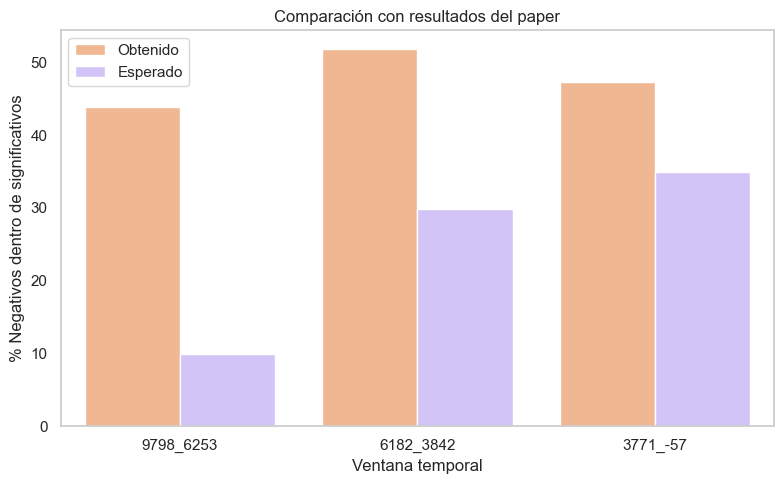

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Datos comparación paper
# -------------------------
comp_data = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [194/442*100, 198/382*100, 87/184*100],
    "Esperado": [9.9, 29.8, 35],
    #"Significativos": [442, 382, 184],
}

comp_df = pd.DataFrame(comp_data)

comp_df_melt = comp_df.melt(
    id_vars="ventana",
    var_name="Tipo",
    value_name="Porcentaje"
)

# -------------------------
# Paleta personalizada
# -------------------------
base_palette = sns.color_palette("pastel", 6)

custom_palette = {
    "Obtenido": base_palette[1],
    "Esperado": base_palette[4],
}

# -------------------------
# Gráfico
# -------------------------
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comp_df_melt,
    x="ventana",
    y="Porcentaje",
    hue="Tipo",
    palette=custom_palette
)

plt.grid(False)
plt.ylabel("% Negativos dentro de significativos")
plt.xlabel("Ventana temporal")
plt.title("Comparación con resultados del paper")
plt.legend(title="")
plt.tight_layout()
plt.show()